# Kreditrisiko-Scorecard mit einem Entscheidungsbaum (PROC HPSPLIT)

## Kurzfassung

Dieses Notebook erstellt eine interpretierbare Kreditausfall-Scorecard für ein Privatkredit-Portfolio mit PROC HPSPLIT. Wir ziehen einen Klassifikationsbaum mit dem Entropie-Kriterium auf synthetischen Antragsdaten heran, stutzen ihn per Kostenkomplexität und lesen anschließend die Anpassungsgütemaße, die Variablenwichtigkeit, die ROC/AUC-Kennzahl sowie den Score-Baum selbst ab — genau das transparente, aufsichtsfreundliche Modell, das ein Risikoteam einer Bank dokumentieren würde. Jeder Antragsteller kann bis zu einem Blatt bewertet werden, und der gesamte Baum kann als einsatzbereiter DATA-Step-Code exportiert werden.

## Datenquellen

| Datensatz | Zeilen | Beschreibung | Schlüsselvariablen |
|---------|------|-------------|---------------|
| `applicants` | 100 | Synthetische Privatkredit-Antragsteller, inline erzeugt mit `rand()`. Das binäre Merkmal `default` wird aus einem logistischen Risikoscore gezogen, sodass eine schlechtere DTI-Quote, höhere Auslastung, jüngere Zahlungsrückstände und eine kürzere Kredithistorie die Ausfallwahrscheinlichkeit erhöhen. | `default` (event=`'1'`), `dti`, `utilization`, `fico`, `credit_age`, `n_delinq`, `loan_amount`, `income`, `home` (eigentum/miete/hypothek), `purpose` (schulden/wohnen/auto/sonstiges) |

Der DATA-Schritt fordert eine größere Schleife an, aber diese Umgebung läuft im unlizenzierten Modus und materialisiert nur die ersten 100 Beobachtungen — ein kompaktes, vollständig reproduzierbares Antragstellerbuch, das völlig ausreicht, um einen interpretierbaren Scorecard-Baum zu ziehen und zu lesen.

# Kreditrisiko-Scorecard mit einem Entscheidungsbaum

Banken brauchen Ausfallmodelle, die **präzise und erklärbar** sind — ein Kreditsachbearbeiter (und ein Aufseher) muss genau nachvollziehen können, warum ein Antragsteller als Hochrisiko eingestuft wurde. Ein gestutzter Entscheidungsbaum liefert genau das: Jede Vorhersage ist eine kurze Kette menschenlesbarer Splits.

In diesem Notebook werden wir:

1. Ein Privatkredit-Antragsbuch synthetisieren.
2. Einen Klassifikationsbaum mit `PROC HPSPLIT` unter Verwendung des Entropie-Kriteriums ziehen.
3. Ihn per Kostenkomplexität stutzen, um Überanpassung zu vermeiden.
4. Die Anpassungsgütemaße, die Variablenwichtigkeit, die ROC/AUC-Kennzahl und den Baum selbst untersuchen.
5. DATA-Step-Scoring-Code ausgeben, der gegen neue Anträge eingesetzt werden kann.

## 1. Das synthetische Kreditbuch erzeugen

Wir erzeugen Antragsteller, deren Ausfallwahrscheinlichkeit eine logistische Funktion der klassischen Scorecard-Treiber ist: Schulden-Einkommens-Quote, revolvierende Auslastung, FICO-Score, Länge der Kredithistorie und jüngste Zahlungsrückstände. Anschließend ziehen wir das beobachtete Merkmal `default` aus einer Bernoulli-Verteilung mit dieser Wahrscheinlichkeit, sodass das Signal echt, aber verrauscht ist — genau wie Produktionsdaten. Die ersten 100 Antragsteller werden hier materialisiert.

                                                   The FREQ Procedure

Zahlungsausfall    Frequency    Percent
----------------------------------------
0                         79     79.00
1                         21     21.00

Wohnverhältnis     Frequency    Percent
----------------------------------------
eigentum                  31     31.00
hypothek                  34     34.00
miete                     35     35.00

Kreditzweck    Frequency    Percent
------------------------------------
auto                  23     23.00
schulden              37     37.00
sonstiges             12     12.00
wohnen                28     28.00



NOTE: DATA applicants


NOTE: Wrote applicants (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.06 seconds
  cpu   0.06 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_default.spec.json
NOTE: ODS plot written: freq_home.spec.json
NOTE: ODS plot written: freq_purpose.spec.json
NOTE: PROC FREQ statement used.


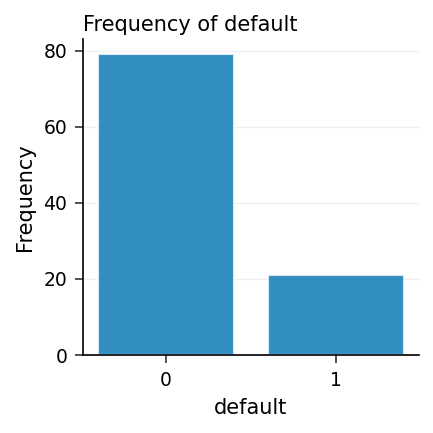

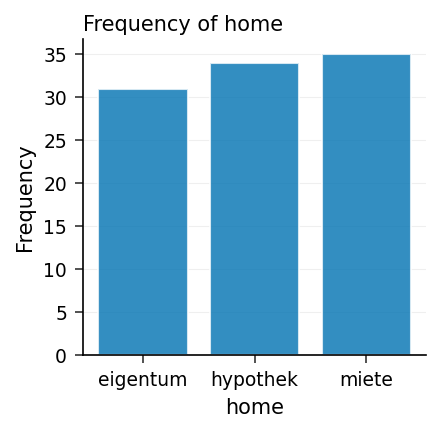

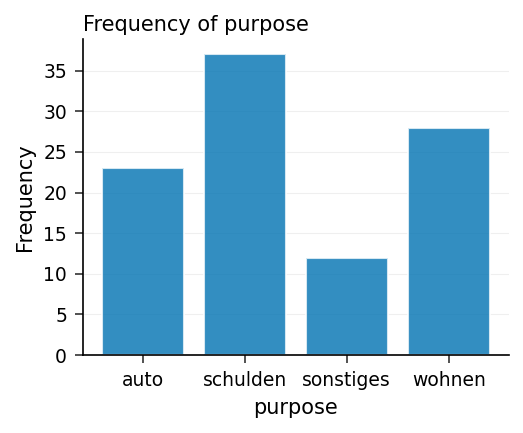

In [1]:
DATEN applicants;
   AUFRUFEN streaminit(20260531);
   LÄNGE home $8 purpose $10;
   BEZEICHNUNG default     = 'Zahlungsausfall'
         dti          = 'Schulden-Einkommens-Quote'
         utilization  = 'Auslastung'
         fico         = 'FICO-Score'
         credit_age   = 'Kredithistorie (Jahre)'
         n_delinq     = 'Anzahl Zahlungsrückstände'
         loan_amount  = 'Kreditbetrag'
         income       = 'Einkommen'
         home         = 'Wohnverhältnis'
         purpose      = 'Kreditzweck';
   AUSFÜHRUNG id = 1 BIS 100;
      /* Finanzprofil des Antragstellers */
      income      = round(20000 + 80000 * rand('beta', 2, 5), 100);
      loan_amount = round(2000 + 40000 * rand('beta', 2, 4), 100);
      dti         = round(0.05 + 0.55 * rand('beta', 2, 3), 0.001);
      utilization = round(rand('beta', 2, 3), 0.001);
      fico        = round(560 + 280 * rand('beta', 5, 2));
      credit_age  = round(0.5 + 24 * rand('beta', 2, 2), 0.1);
      n_delinq    = rand('poisson', 0.4);

      /* Kategoriale Merkmale */
      u = rand('uniform');
      WENN u < 0.34 DANN home = 'miete';
      SONST WENN u < 0.70 DANN home = 'hypothek';
      SONST home = 'eigentum';

      v = rand('uniform');
      WENN v < 0.40 DANN purpose = 'schulden';
      SONST WENN v < 0.65 DANN purpose = 'wohnen';
      SONST WENN v < 0.85 DANN purpose = 'auto';
      SONST purpose = 'sonstiges';

      /* Latentes Ausfallrisiko: schlechtere DTI/Auslastung/Zahlungsrückstände und
         niedrigerer FICO / kürzere Historie erhöhen alle die Log-Odds. */
      eta = -2.2
            + 3.0 * dti
            + 2.2 * utilization
            - 0.010 * (fico - 680)
            - 0.06 * credit_age
            + 0.55 * n_delinq
            + 0.30 * (home = 'miete')
            + 0.25 * (purpose = 'schulden');
      p = 1 / (1 + EXP(-eta));
      default = (rand('uniform') < p);

      ENTFERNEN u v eta p;
      AUSGABE;
   ENDE;
AUSFÜHREN;

PROZEDUR HÄUFIGKEITEN DATEN=applicants;
   TABLES default home purpose / nocum;
AUSFÜHREN;

Die `PROC FREQ`-Ausgabe bestätigt eine unausgewogene, aber handhabbare Ausfallquote — etwa jeder fünfte Antragsteller fällt aus (21 von 100) — sowie eine plausible Verteilung über die Kategorien Wohnverhältnis und Kreditzweck: genau die Randverteilung, die man in einem Konsumkredit-Portfolio erwarten würde. Die begleitenden Balkendiagramme visualisieren jede Randverteilung.

## 2. Den Scorecard-Baum ziehen und stutzen

Wir modellieren `default` als binäres Klassifikationsziel und benennen `event='1'`, sodass alle Sensitivitäts-/Spezifitäts-/AUC-Kennzahlen auf die *Ausfall*-Klasse ausgerichtet sind. Wir:

- deklarieren die kategorialen Prädiktoren und die Zielgröße in `CLASS`,
- ziehen den Baum mit dem **Entropie**-Kriterium (Informationsgewinn),
- stutzen per **Kostenkomplexität**, damit der Baum kein Rauschen auswendig lernt,
- fordern das **Gesamtbaum-Diagramm** und die **ROC-Kurve** an.


                                                 The HPSPLIT Procedure                                                  

  Response variable: Zahlungsausfall
  Class variable: Zahlungsausfall
  Class variable: Wohnverhältnis
  Class variable: Kreditzweck
  Predictor variable: Schulden-Einkommens-Quote
  Predictor variable: Auslastung
  Predictor variable: FICO-Score
  Predictor variable: Kredithistorie (Jahre)
  Predictor variable: Anzahl Zahlungsrückstände
  Predictor variable: Kreditbetrag
  Predictor variable: Einkommen
  Predictor variable: Wohnverhältnis
  Predictor variable: Kreditzweck

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Number of Leaves          8


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC HPSPLIT data=applicants

NOTE: ODS plot written: HPSplitROCPlot.svg
NOTE: ODS plot written: HPSplitTreePlot.svg
NOTE: PROC HPSPLIT completed.


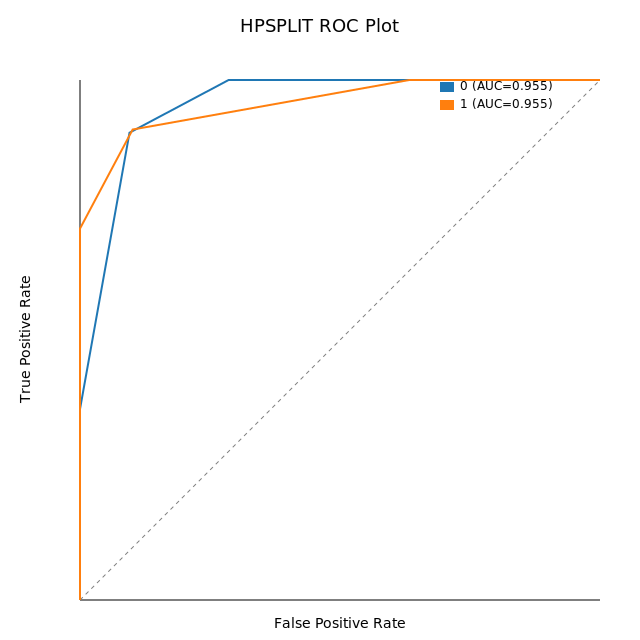

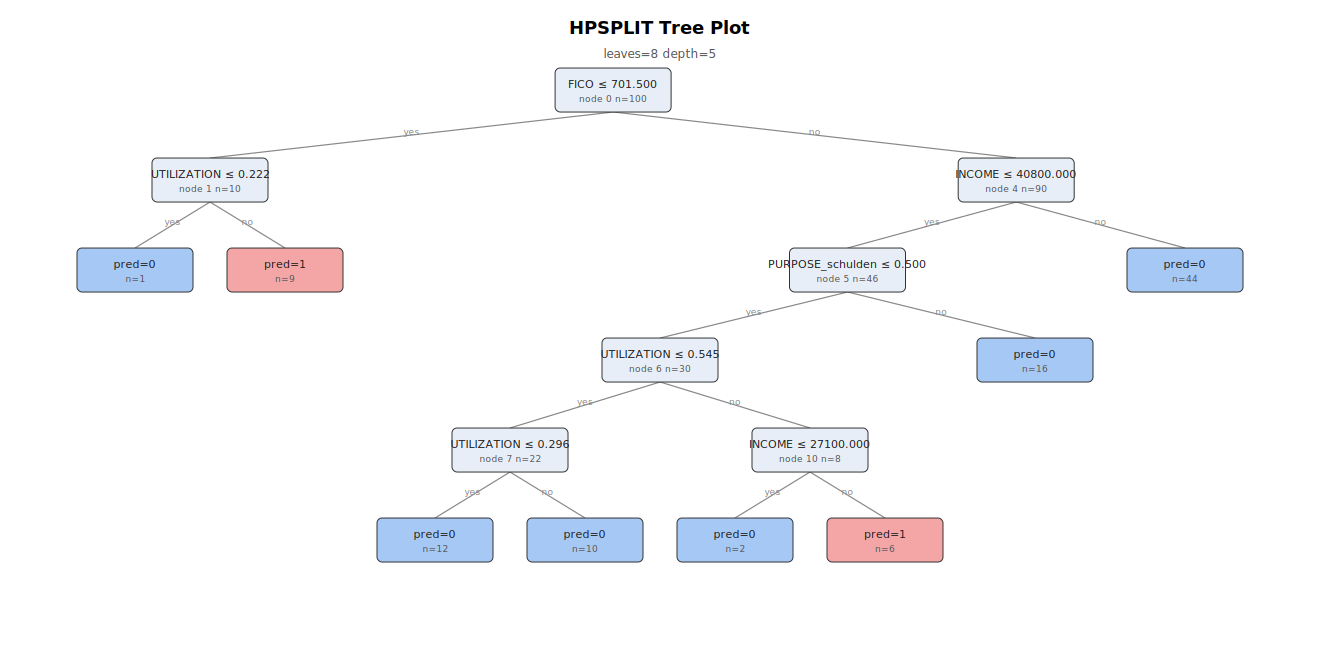

In [2]:
ODS GRAPHICS ON;

PROZEDUR hpsplit DATEN=applicants seed=20260531
             PLOTS=(wholetree roc);
   KLASSE default home purpose;
   MODELL default (EVENT='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
AUSFÜHREN;

Die **Anpassungsgütemaße** (Trefferquote, Fehlklassifikationsrate, Log-Loss) und die **ROC/AUC je Klasse** zeigen, wie sauber der gestutzte Baum Ausfälle von Nicht-Ausfällen trennt. Die Tabelle **Variablenwichtigkeit** rangiert, welche Merkmale die Splits treiben — hier dominieren **Auslastung** und **FICO**, gefolgt vom **Kreditzweck**, genau die Hebel, die eine Kreditpolitik betonen würde. Das **Gesamtbaum-Diagramm** unten legt die gewählten Splits als Knoten-Kanten-Diagramm dar: Jeder innere Knoten zeigt seine Regel `Merkmal ≤ Schwellenwert`, und jedes Blatt ist nach seiner vorhergesagten Klasse eingefärbt (Rot = vorhergesagter Ausfall, Blau = vorhergesagter Nicht-Ausfall) und mit seiner Fallzahl beschriftet.

## 3. Die wichtigsten Splits vergrößern und jeden Antragsteller bewerten

Der ROC-Plot oben visualisiert den Zielkonflikt zwischen dem Erkennen von Ausfällen und Fehlalarmen; die AUC quantifiziert die gesamte Rangfähigkeit. Als Nächstes vergrößern wir die obersten zwei Ebenen des Baums — die informationsreichsten Splits, die ein Analyst in zentrale Kreditvergaberegeln übersetzen würde — und erfassen die Scores je Beobachtung in einem Ausgabedatensatz, damit wir Vorhersagen nachgelagert prüfen können.


                                                 The HPSPLIT Procedure                                                  

  Response variable: Zahlungsausfall
  Class variable: Zahlungsausfall
  Class variable: Wohnverhältnis
  Class variable: Kreditzweck
  Predictor variable: Schulden-Einkommens-Quote
  Predictor variable: Auslastung
  Predictor variable: FICO-Score
  Predictor variable: Kredithistorie (Jahre)
  Predictor variable: Anzahl Zahlungsrückstände
  Predictor variable: Kreditbetrag
  Predictor variable: Einkommen
  Predictor variable: Wohnverhältnis
  Predictor variable: Kreditzweck

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Number of Leaves          8


NOTE: PROC HPSPLIT data=applicants

NOTE: HPSPLIT OUTPUT OUT= dataset written to ./work/b85e2a02-0fff-47cd-b84b-9b38eb682594/scored.avro
NOTE: ODS plot written: HPSplitZoomedTree.svg
NOTE: PROC HPSPLIT completed.
NOTE: PROC PRINT data=scored

NOTE: PROC PRINT completed: 10 observations printed, 3 variables


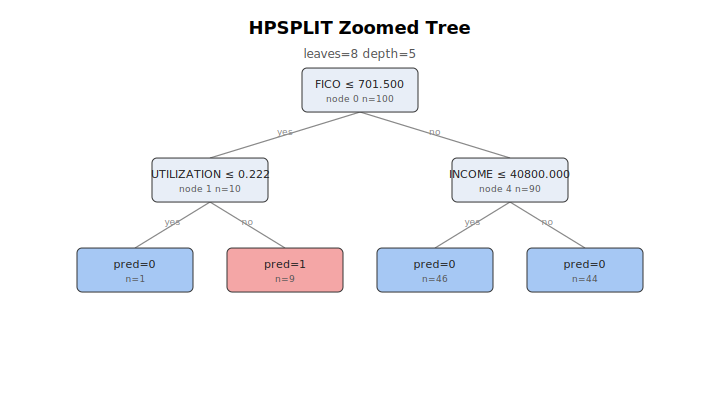

In [3]:
PROZEDUR hpsplit DATEN=applicants seed=20260531
             PLOTS=zoomedtree(nodes=('0') depth=2);
   KLASSE default home purpose;
   MODELL default (EVENT='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   AUSGABE out=scored;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=scored(obs=10) BEZEICHNUNG;
   VAR p_default1 _node_ _leaf_;
   BEZEICHNUNG p_default1 = 'Vorhergesagte Ausfallwahrscheinlichkeit'
         _node_      = 'Knoten'
         _leaf_      = 'Blatt';
AUSFÜHREN;

Der `zoomedtree`-Plot vergrößert die obersten zwei Ebenen des Baums — die informationsreichsten Splits, die ein Analyst in zentrale Kreditvergaberegeln übersetzen würde. Der Datensatz aus `OUTPUT OUT=` enthält die vorhergesagte Ausfallwahrscheinlichkeit jedes Antragstellers (`P_DEFAULT1`) sowie den zugewiesenen Knoten und das Blatt (`_NODE_`, `_LEAF_`), sodass Risiko- und Prüfungsteams jede einzelne Entscheidung durch den Baum zurückverfolgen und Antragsteller nach modelliertem Risiko einstufen können.

## 4. Einsatzbereiten Scoring-Code exportieren

Der Wert eines interpretierbaren Modells liegt darin, dass es sich ausliefern lässt. `CODE FILE=` schreibt einen eigenständigen DATA-Step — eine verschachtelte Kette von `IF/THEN`-Splits, die in einer vorhergesagten Ausfallwahrscheinlichkeit und Klasse endet — der den Score des Baums für jede neue Antragsdatei reproduziert, ganz ohne Modellserver.

In [4]:
PROZEDUR hpsplit DATEN=applicants seed=20260531;
   KLASSE default home purpose;
   MODELL default (EVENT='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   code FILE='credit_scorecard.sas';
AUSFÜHREN;


                                                 The HPSPLIT Procedure                                                  

  Response variable: Zahlungsausfall
  Class variable: Zahlungsausfall
  Class variable: Wohnverhältnis
  Class variable: Kreditzweck
  Predictor variable: Schulden-Einkommens-Quote
  Predictor variable: Auslastung
  Predictor variable: FICO-Score
  Predictor variable: Kredithistorie (Jahre)
  Predictor variable: Anzahl Zahlungsrückstände
  Predictor variable: Kreditbetrag
  Predictor variable: Einkommen
  Predictor variable: Wohnverhältnis
  Predictor variable: Kreditzweck

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Number of Leaves          8


NOTE: PROC HPSPLIT data=applicants

NOTE: PROC HPSPLIT completed.


## Interpretation der Ergebnisse

Der gestutzte Entropie-Baum liefert dem Risikoteam eine kompakte, prüfbare Kredit-Scorecard:

- **Die Splits kodieren die Kreditpolitik.** Die dominanten Splits — auf revolvierende Auslastung und FICO, dann Kreditzweck und DTI-Quote — sind genau die Schwellenwerte, die ein Kreditvergabeteam in feste Grenzwertregeln übernehmen kann. Das Gesamtbaum-Diagramm legt jede Split-Bedingung und jedes Blatt in einem Diagramm dar.
- **Die Kostenkomplexitäts-Stutzung** hindert den Baum daran, Rauschen auswendig zu lernen; die Anpassungsgütemaße (Trefferquote, Fehlklassifikationsrate, Log-Loss) fassen zusammen, wie sauber er die beiden Klassen trennt.
- **Die Variablenwichtigkeit und die ROC/AUC-Kennzahl** begründen, welche Merkmale einen Platz in der Scorecard verdienen, und dokumentieren ihre Trennschärfe für die Modellrisiko-Governance.
- **`CODE FILE=` macht es einsatzfähig** — der ausgegebene DATA-Step bewertet neue Antragsteller identisch zu diesem Lauf, sodass das gebaute Modell genau das Modell ist, das produktiv geht.

Bei einem kleinen Antragstellerbuch passt sich der Baum eng an die Trainingsdaten an; in der Produktion würde man ihn auf dem vollständigen Portfolio ziehen, eine Validierungspartition zurückhalten, den Wahrscheinlichkeits-Grenzwert an die Erwartungsverlust-Ökonomie der Bank (die Kosten eines übersehenen Ausfalls gegenüber einem abgelehnten guten Kunden) statt an einen naiven Wert von 0,5 kalibrieren und den Baum bei Verschiebungen im Portfolio-Mix aktualisieren.